In [ ]:
import tensorflow as tf
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    accuracy_score
)

from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# --------------------------------------------------
# GPU CHECK
# --------------------------------------------------

gpus = tf.config.list_physical_devices('GPU')
print("Num GPUs Available:", len(gpus))

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print("GPU memory growth enabled. Using:", gpus)
    except RuntimeError as e:
        print(e)
else:
    print("No GPU detected. Go to Runtime > Change runtime type > GPU in Colab.")

# --------------------------------------------------
# PLOTS DIRECTORY
# --------------------------------------------------

PLOTS_DIR = "plots"
os.makedirs(PLOTS_DIR, exist_ok=True)

# --------------------------------------------------
# PLOT SETTINGS
# --------------------------------------------------

matplotlib.rcParams['font.weight'] = 'bold'
matplotlib.rcParams['axes.labelweight'] = 'bold'
matplotlib.rcParams['axes.titleweight'] = 'bold'
matplotlib.rcParams['figure.dpi'] = 100


def save_bold_plot(fig, filename, plots_dir=PLOTS_DIR):
    for ax in fig.get_axes():

        if ax.get_title():
            ax.set_title(
                ax.get_title(),
                fontweight='bold',
                fontsize=13
            )

        if ax.get_xlabel():
            ax.set_xlabel(
                ax.get_xlabel(),
                fontweight='bold',
                fontsize=11
            )

        if ax.get_ylabel():
            ax.set_ylabel(
                ax.get_ylabel(),
                fontweight='bold',
                fontsize=11
            )

        leg = ax.get_legend()

        if leg is not None:
            for text in leg.get_texts():
                text.set_fontweight('bold')

    filepath = os.path.join(plots_dir, filename)

    fig.savefig(
        filepath,
        format='png',
        dpi=150,
        bbox_inches='tight'
    )

    print(f"Saved: {filepath}")
    plt.show()


# --------------------------------------------------
# GLOBAL CONSTANTS
# --------------------------------------------------

NUM_CLASSES = 10
INPUT_SHAPE = (32, 32, 3)

class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

print("\nSetup complete.")
print("TensorFlow version:", tf.__version__)
print("Plots directory:", PLOTS_DIR)

Num GPUs Available: 1
GPU memory growth enabled. Using: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

Setup complete.
TensorFlow version: 2.20.0
Plots directory: plots


In [ ]:
# --------------------------------------------------
# LOAD CIFAR-10 DATASET
# --------------------------------------------------

(x_train_full, y_train_full), (x_test, y_test) = cifar10.load_data()

# --------------------------------------------------
# NORMALIZE PIXEL VALUES TO [0, 1]
# --------------------------------------------------

x_train_full = x_train_full.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# --------------------------------------------------
# TRAIN / VALIDATION SPLIT
# 90% training, 10% validation
# --------------------------------------------------

x_train, x_val, y_train_labels, y_val_labels = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.1,
    random_state=42,
    stratify=y_train_full
)

# --------------------------------------------------
# ONE-HOT ENCODE LABELS
# --------------------------------------------------

y_train = to_categorical(y_train_labels, NUM_CLASSES)
y_val = to_categorical(y_val_labels, NUM_CLASSES)
y_test_cat = to_categorical(y_test, NUM_CLASSES)

# Original integer labels for evaluation
y_true = y_test.flatten()

# --------------------------------------------------
# PRINT DATASET DIMENSIONS
# --------------------------------------------------

print("Training set shape   :", x_train.shape, y_train.shape)
print("Validation set shape :", x_val.shape, y_val.shape)
print("Testing set shape    :", x_test.shape, y_test_cat.shape)

print("\nNumber of training images   :", len(x_train))
print("Number of validation images :", len(x_val))
print("Number of testing images    :", len(x_test))
print("Number of classes           :", NUM_CLASSES)
print("Image shape                 :", INPUT_SHAPE)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 601s 4us/step
Training set shape   : (45000, 32, 32, 3) (45000, 10)
Validation set shape : (5000, 32, 32, 3) (5000, 10)
Testing set shape    : (10000, 32, 32, 3) (10000, 10)

Number of training images   : 45000
Number of validation images : 5000
Number of testing images    : 10000
Number of classes           : 10
Image shape                 : (32, 32, 3)


Saved: plots/sample_cifar10_images.png


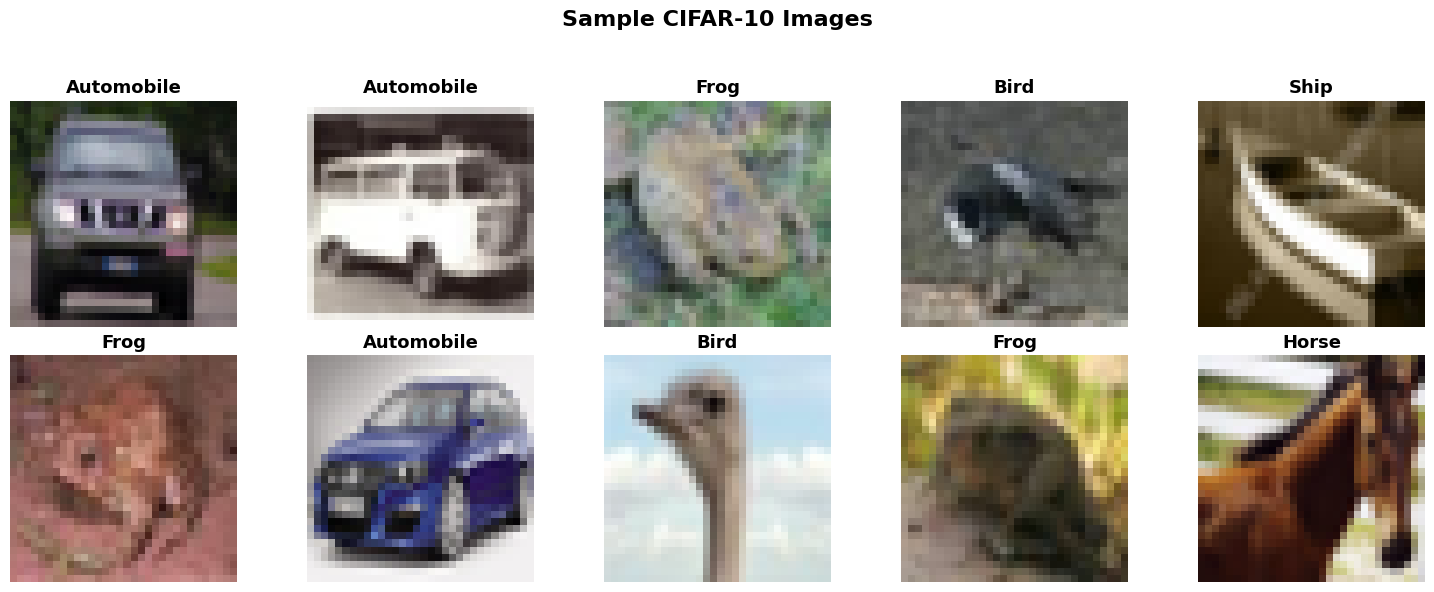

In [ ]:
# --------------------------------------------------
# DISPLAY 10 SAMPLE CIFAR-10 IMAGES
# --------------------------------------------------

fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i])
    ax.set_title(class_names[y_train_labels[i][0]])
    ax.axis('off')

fig.suptitle(
    'Sample CIFAR-10 Images',
    fontsize=16,
    fontweight='bold'
)

plt.tight_layout(rect=[0, 0, 1, 0.94])

save_bold_plot(
    fig,
    'sample_cifar10_images.png'
)

In [ ]:
# --------------------------------------------------
# VGG16 TRANSFER LEARNING
# --------------------------------------------------

from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras import layers, models, optimizers

# --------------------------------------------------
# VGG16 PREPROCESSING
# VGG16 ImageNet weights expect ImageNet-style input
# --------------------------------------------------

x_train_vgg = preprocess_input(x_train * 255.0)
x_val_vgg = preprocess_input(x_val * 255.0)
x_test_vgg = preprocess_input(x_test * 255.0)

print("VGG16 preprocessing complete.")
print("Training data shape:", x_train_vgg.shape)
print("Validation data shape:", x_val_vgg.shape)
print("Test data shape:", x_test_vgg.shape)


# --------------------------------------------------
# BUILD TRANSFER LEARNING MODEL
# --------------------------------------------------

def build_transfer_model(
    base_model_class,
    dense_units=128,
    learning_rate=0.001,
    optimizer_name='adam'
):

    # Load pretrained ImageNet model without original classifier
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    # Freeze convolutional base
    base_model.trainable = False

    # Build new classifier
    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    # Select optimizer
    if optimizer_name.lower() == 'adam':
        optimizer = optimizers.Adam(learning_rate=learning_rate)

    elif optimizer_name.lower() == 'sgd':
        optimizer = optimizers.SGD(learning_rate=learning_rate)

    else:
        raise ValueError("Optimizer must be 'adam' or 'sgd'.")

    # Compile
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model, base_model


# --------------------------------------------------
# CREATE VGG16 MODEL
# --------------------------------------------------

vgg_model, vgg_base = build_transfer_model(
    VGG16,
    dense_units=128,
    learning_rate=0.001,
    optimizer_name='adam'
)

# --------------------------------------------------
# DISPLAY MODEL SUMMARY
# --------------------------------------------------

vgg_model.summary()

VGG16 preprocessing complete.
Training data shape: (45000, 32, 32, 3)
Validation data shape: (5000, 32, 32, 3)
Test data shape: (10000, 32, 32, 3)
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ vgg16 (Functional)              │ (None, 1, 1, 512)      │    14,714,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,781,642 (56.39 MB)

 Trainable params: 66,954 (261.54 KB)

 Non-trainable params: 14,714,688 (56.13 MB)

In [ ]:
# --------------------------------------------------
# TRAIN VGG16 TRANSFER LEARNING MODEL
# --------------------------------------------------

BATCH_SIZE = 32
EPOCHS_MAIN = 15

print("Starting VGG16 transfer learning training...")
print(f"Batch size: {BATCH_SIZE}")
print(f"Epochs: {EPOCHS_MAIN}")
print("Optimizer: Adam")
print("Learning rate: 0.001")

start_time = time.time()

history_vgg = vgg_model.fit(
    x_train_vgg,
    y_train,
    validation_data=(x_val_vgg, y_val),
    epochs=EPOCHS_MAIN,
    batch_size=BATCH_SIZE,
    verbose=1
)

training_time_vgg = time.time() - start_time

print(f"\nTraining completed in {training_time_vgg / 60:.2f} minutes.")

Starting VGG16 transfer learning training...
Batch size: 32
Epochs: 15
Optimizer: Adam
Learning rate: 0.001
Epoch 1/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 10ms/step - accuracy: 0.5294 - loss: 1.9487 - val_accuracy: 0.6022 - val_loss: 1.1603
Epoch 2/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6436 - loss: 1.0286 - val_accuracy: 0.6418 - val_loss: 1.0607
Epoch 3/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6773 - loss: 0.9258 - val_accuracy: 0.6472 - val_loss: 1.0482
Epoch 4/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.6953 - loss: 0.8674 - val_accuracy: 0.6412 - val_loss: 1.0810
Epoch 5/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7137 - loss: 0.8167 - val_accuracy: 0.6422 - val_loss: 1.0953
Epoch 6/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7297 - loss: 0.7678 - val_accuracy: 0.6496 - val_loss: 1.1177
Epoch 7/15
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7457 - loss: 0.7216 - val_accuracy: 

Saved: plots/training_accuracy.png


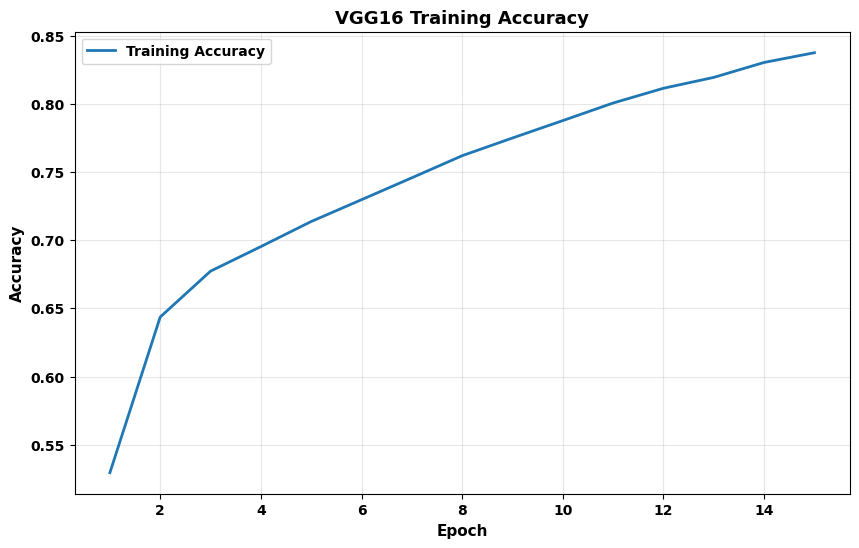

Saved: plots/validation_accuracy.png


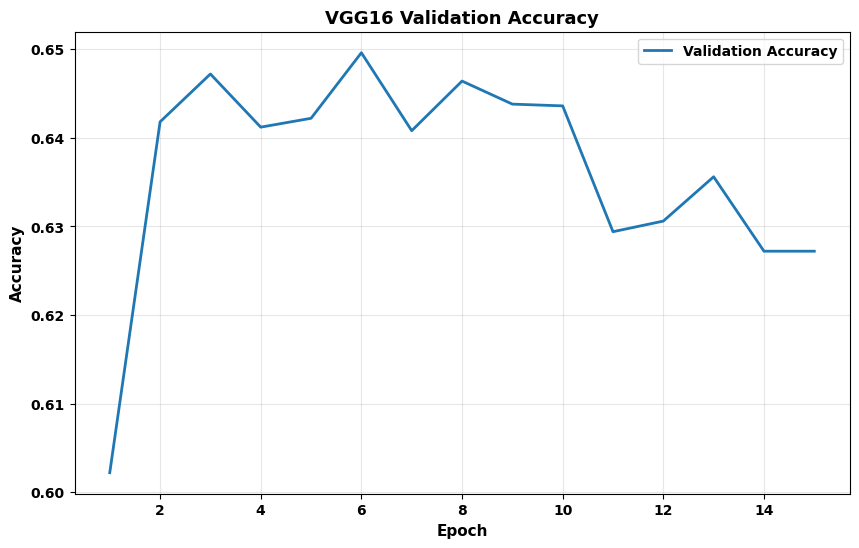

Saved: plots/training_loss.png


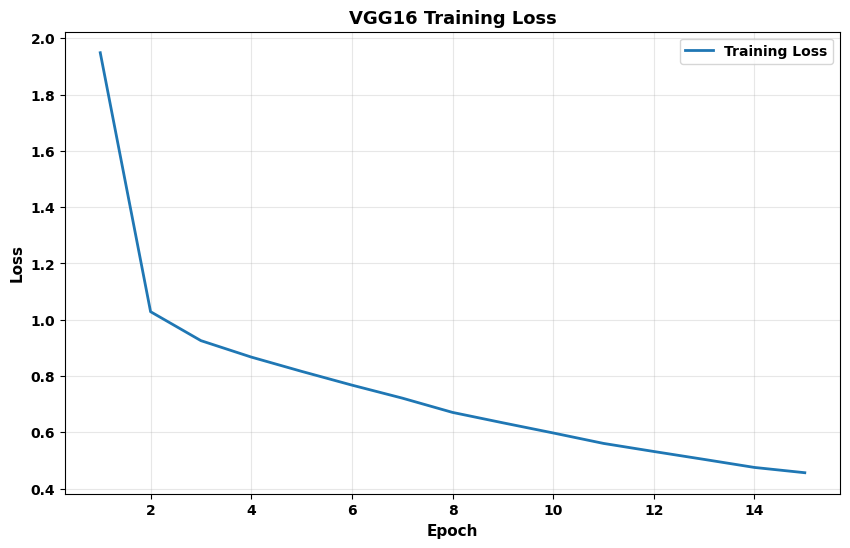

Saved: plots/validation_loss.png


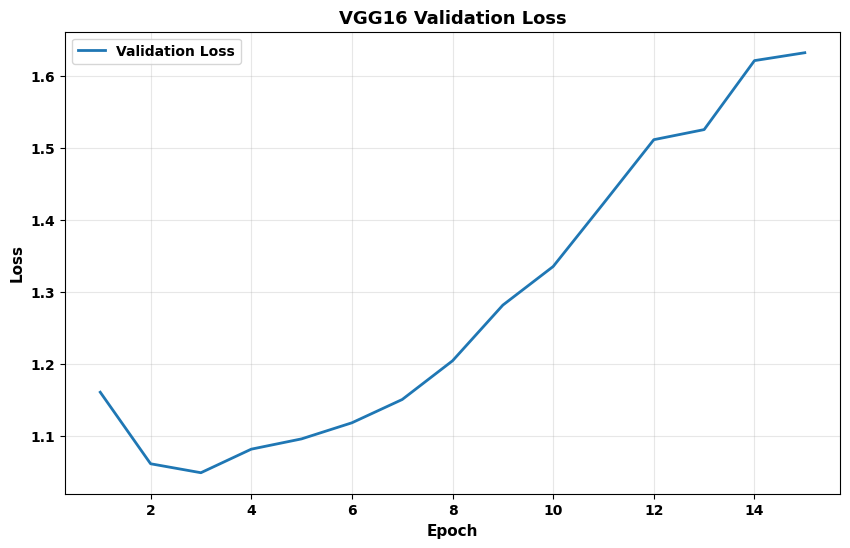


VGG16 TRAINING SUMMARY
Best Validation Accuracy : 0.6496 (64.96%)
Best Validation Accuracy Epoch : 6
Lowest Validation Loss : 1.0482
Lowest Validation Loss Epoch : 3
Final Training Accuracy : 0.8375 (83.75%)
Final Validation Accuracy : 0.6272 (62.72%)


In [ ]:
# --------------------------------------------------
# VGG16 TRAINING & VALIDATION PLOTS
# --------------------------------------------------

epochs_range = range(1, len(history_vgg.history['accuracy']) + 1)

# --------------------------------------------------
# 1. TRAINING ACCURACY
# --------------------------------------------------

fig = plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_vgg.history['accuracy'],
    linewidth=2,
    label='Training Accuracy'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('VGG16 Training Accuracy', fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

save_bold_plot(
    fig,
    'training_accuracy.png'
)


# --------------------------------------------------
# 2. VALIDATION ACCURACY
# --------------------------------------------------

fig = plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_vgg.history['val_accuracy'],
    linewidth=2,
    label='Validation Accuracy'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Accuracy', fontweight='bold')
plt.title('VGG16 Validation Accuracy', fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

save_bold_plot(
    fig,
    'validation_accuracy.png'
)


# --------------------------------------------------
# 3. TRAINING LOSS
# --------------------------------------------------

fig = plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_vgg.history['loss'],
    linewidth=2,
    label='Training Loss'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('VGG16 Training Loss', fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

save_bold_plot(
    fig,
    'training_loss.png'
)


# --------------------------------------------------
# 4. VALIDATION LOSS
# --------------------------------------------------

fig = plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history_vgg.history['val_loss'],
    linewidth=2,
    label='Validation Loss'
)

plt.xlabel('Epoch', fontweight='bold')
plt.ylabel('Loss', fontweight='bold')
plt.title('VGG16 Validation Loss', fontweight='bold', fontsize=15)
plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

save_bold_plot(
    fig,
    'validation_loss.png'
)


# --------------------------------------------------
# BEST VALIDATION RESULTS
# --------------------------------------------------

best_val_acc_epoch = np.argmax(
    history_vgg.history['val_accuracy']
) + 1

best_val_acc = max(
    history_vgg.history['val_accuracy']
)

best_val_loss_epoch = np.argmin(
    history_vgg.history['val_loss']
) + 1

best_val_loss = min(
    history_vgg.history['val_loss']
)

print("\n" + "=" * 55)
print("VGG16 TRAINING SUMMARY")
print("=" * 55)

print(
    f"Best Validation Accuracy : "
    f"{best_val_acc:.4f} ({best_val_acc * 100:.2f}%)"
)

print(
    f"Best Validation Accuracy Epoch : "
    f"{best_val_acc_epoch}"
)

print(
    f"Lowest Validation Loss : "
    f"{best_val_loss:.4f}"
)

print(
    f"Lowest Validation Loss Epoch : "
    f"{best_val_loss_epoch}"
)

print(
    f"Final Training Accuracy : "
    f"{history_vgg.history['accuracy'][-1]:.4f} "
    f"({history_vgg.history['accuracy'][-1] * 100:.2f}%)"
)

print(
    f"Final Validation Accuracy : "
    f"{history_vgg.history['val_accuracy'][-1]:.4f} "
    f"({history_vgg.history['val_accuracy'][-1] * 100:.2f}%)"
)

print("=" * 55)

In [ ]:
# --------------------------------------------------
# TASK 4: FINE-TUNING VGG16
# --------------------------------------------------

print("=" * 60)
print("VGG16 FINE-TUNING")
print("=" * 60)

# --------------------------------------------------
# UNFREEZE ONLY THE LAST CONVOLUTIONAL BLOCK
# --------------------------------------------------

vgg_base.trainable = True

for layer in vgg_base.layers:
    if layer.name.startswith("block5"):
        layer.trainable = True
    else:
        layer.trainable = False

# Count trainable/non-trainable parameters
trainable_params = np.sum([
    np.prod(v.shape) for v in vgg_model.trainable_weights
])

non_trainable_params = np.sum([
    np.prod(v.shape) for v in vgg_model.non_trainable_weights
])

print("\nTrainable parameters after unfreezing Block 5:",
      f"{trainable_params:,}")

print("Non-trainable parameters:",
      f"{non_trainable_params:,}")

print("\nTrainable layers:")
for layer in vgg_base.layers:
    if layer.trainable:
        print(layer.name)

# --------------------------------------------------
# RECOMPILE WITH A SMALL LEARNING RATE
# --------------------------------------------------
# A smaller learning rate is used during fine-tuning
# so pretrained features are not changed too aggressively.

vgg_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# --------------------------------------------------
# FINE-TUNE FOR 8 MORE EPOCHS
# --------------------------------------------------

EPOCHS_FINETUNE = 8

start_time_ft = time.time()

history_ft = vgg_model.fit(
    x_train_vgg,
    y_train,
    validation_data=(x_val_vgg, y_val),
    epochs=EPOCHS_FINETUNE,
    batch_size=BATCH_SIZE,
    verbose=1
)

fine_tuning_time = time.time() - start_time_ft

# --------------------------------------------------
# BEST FINE-TUNING VALIDATION ACCURACY
# --------------------------------------------------

best_ft_val_acc = max(
    history_ft.history['val_accuracy']
)

best_ft_epoch = (
    np.argmax(history_ft.history['val_accuracy']) + 1
)

final_ft_train_acc = (
    history_ft.history['accuracy'][-1]
)

final_ft_val_acc = (
    history_ft.history['val_accuracy'][-1]
)

# --------------------------------------------------
# COMPARE BEFORE VS AFTER FINE-TUNING
# --------------------------------------------------

best_before_ft = max(
    history_vgg.history['val_accuracy']
)

improvement = best_ft_val_acc - best_before_ft

print("\n" + "=" * 60)
print("FINE-TUNING SUMMARY")
print("=" * 60)

print(
    f"Best Validation Accuracy Before Fine-Tuning : "
    f"{best_before_ft * 100:.2f}%"
)

print(
    f"Best Validation Accuracy After Fine-Tuning  : "
    f"{best_ft_val_acc * 100:.2f}%"
)

print(
    f"Improvement                                : "
    f"{improvement * 100:+.2f}%"
)

print(
    f"Best Fine-Tuning Epoch                     : "
    f"{best_ft_epoch}"
)

print(
    f"Final Fine-Tuning Training Accuracy       : "
    f"{final_ft_train_acc * 100:.2f}%"
)

print(
    f"Final Fine-Tuning Validation Accuracy      : "
    f"{final_ft_val_acc * 100:.2f}%"
)

print(
    f"Fine-Tuning Time                           : "
    f"{fine_tuning_time / 60:.2f} minutes"
)

print("=" * 60)

VGG16 FINE-TUNING

Trainable parameters after unfreezing Block 5: 7,146,378
Non-trainable parameters: 7,635,264

Trainable layers:
block5_conv1
block5_conv2
block5_conv3
block5_pool
Epoch 1/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 26s 15ms/step - accuracy: 0.8402 - loss: 0.4477 - val_accuracy: 0.6516 - val_loss: 1.5811
Epoch 2/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.8932 - loss: 0.3036 - val_accuracy: 0.6758 - val_loss: 1.5631
Epoch 3/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9211 - loss: 0.2290 - val_accuracy: 0.6678 - val_loss: 1.5790
Epoch 4/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9390 - loss: 0.1807 - val_accuracy: 0.6728 - val_loss: 1.6165
Epoch 5/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 12ms/step - accuracy: 0.9523 - loss: 0.1473 - val_accuracy: 0.6828 - val_loss: 1.6823
Epoch 6/8
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 18s 13ms/step - accuracy: 0.9630 - loss: 0.1186 - val_accuracy: 0.6860 - val_loss: 1.6735
Epoch 7/8
1407/1407 ━━━━━━━━━━━━

Saved: plots/before_after_finetuning_accuracy.png


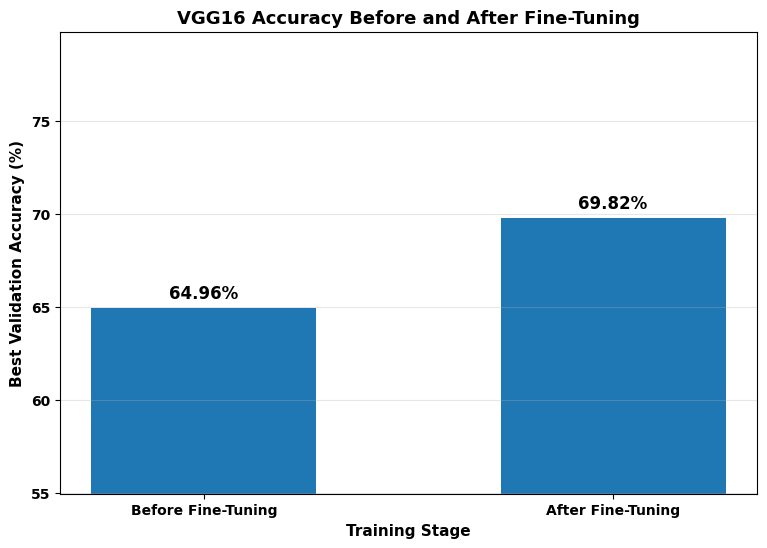


BEFORE vs AFTER FINE-TUNING
Before Fine-Tuning : 64.96%
After Fine-Tuning  : 69.82%
Change             : +4.86%


In [ ]:
# --------------------------------------------------
# BEFORE vs AFTER FINE-TUNING
# --------------------------------------------------

best_before_ft = max(history_vgg.history['val_accuracy'])
best_after_ft = max(history_ft.history['val_accuracy'])

fig = plt.figure(figsize=(9, 6))

labels = [
    'Before Fine-Tuning',
    'After Fine-Tuning'
]

values = [
    best_before_ft * 100,
    best_after_ft * 100
]

bars = plt.bar(
    labels,
    values,
    width=0.55
)

plt.ylabel('Best Validation Accuracy (%)', fontweight='bold')
plt.xlabel('Training Stage', fontweight='bold')
plt.title(
    'VGG16 Accuracy Before and After Fine-Tuning',
    fontweight='bold',
    fontsize=15
)

plt.ylim(
    max(0, min(values) - 10),
    min(100, max(values) + 10)
)

plt.xticks(fontweight='bold')
plt.yticks(fontweight='bold')

# Add accuracy values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=12
    )

plt.grid(axis='y', alpha=0.3)

save_bold_plot(
    fig,
    'before_after_finetuning_accuracy.png'
)

# --------------------------------------------------
# PRINT COMPARISON
# --------------------------------------------------

print("\n" + "=" * 55)
print("BEFORE vs AFTER FINE-TUNING")
print("=" * 55)

print(
    f"Before Fine-Tuning : {best_before_ft * 100:.2f}%"
)

print(
    f"After Fine-Tuning  : {best_after_ft * 100:.2f}%"
)

print(
    f"Change             : "
    f"{(best_after_ft - best_before_ft) * 100:+.2f}%"
)

print("=" * 55)

TASK 5: VGG16 MODEL EVALUATION AFTER FINE-TUNING

Generating predictions on the CIFAR-10 test set...
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step

PERFORMANCE METRICS
Testing Accuracy  : 69.76%
Precision (Macro) : 69.75%
Recall (Macro)    : 69.76%
F1-score (Macro)  : 69.70%
Evaluation Time   : 5.24 seconds

CLASSIFICATION REPORT
              precision    recall  f1-score   support

    Airplane     0.7467    0.7460    0.7464      1000
  Automobile     0.7766    0.8100    0.7930      1000
        Bird     0.6329    0.5740    0.6020      1000
         Cat     0.5268    0.5300    0.5284      1000
        Deer     0.6450    0.6160    0.6302      1000
         Dog     0.6025    0.6350    0.6183      1000
        Frog     0.7386    0.7430    0.7408      1000
       Horse     0.7518    0.7360    0.7438      1000
        Ship     0.8265    0.7860    0.8057      1000
       Truck     0.7273    0.8000    0.7619      1000

    accuracy                         0.6976     10000
   macro avg     0.697

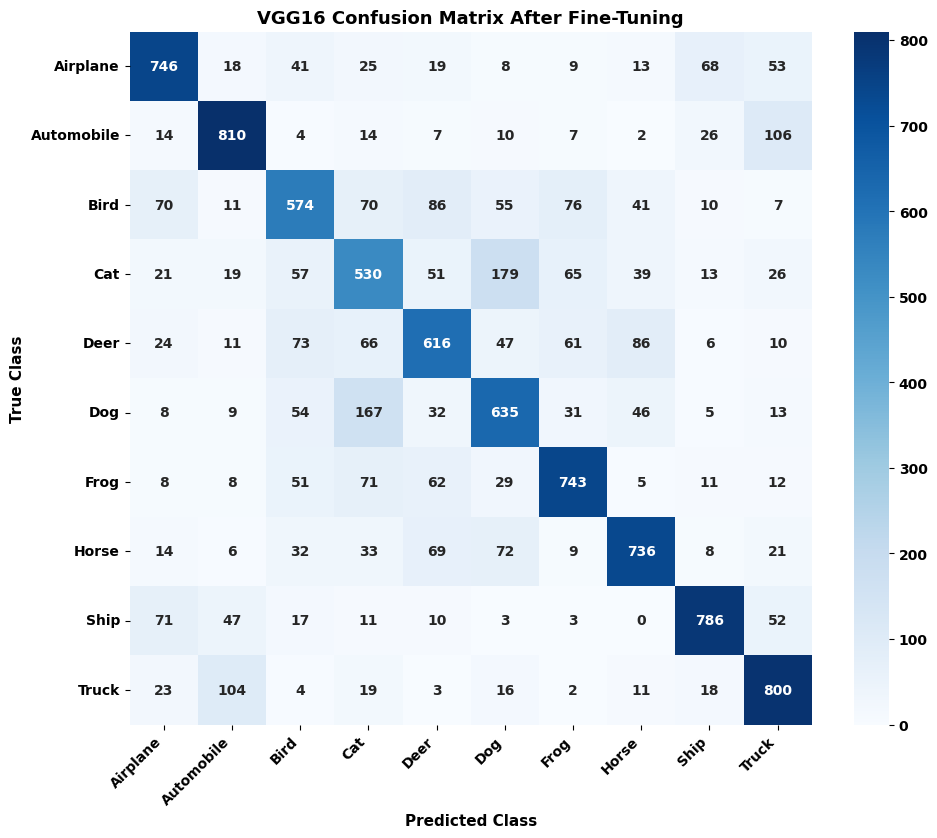


FINAL VGG16 RESULTS
Testing Accuracy : 69.76%
Precision        : 69.75%
Recall           : 69.76%
F1-score         : 69.70%
Total Parameters : 14,781,642
Training Time    : 3.18 minutes
Fine-Tuning Time : 2.49 minutes


In [ ]:
# --------------------------------------------------
# TASK 5: MODEL EVALUATION
# --------------------------------------------------

print("=" * 70)
print("TASK 5: VGG16 MODEL EVALUATION AFTER FINE-TUNING")
print("=" * 70)

# --------------------------------------------------
# PREDICTIONS ON TEST SET
# --------------------------------------------------

print("\nGenerating predictions on the CIFAR-10 test set...")

start_time_eval = time.time()

y_pred_prob = vgg_model.predict(
    x_test_vgg,
    batch_size=32,
    verbose=1
)

evaluation_time = time.time() - start_time_eval

# Convert probabilities to predicted class labels
y_pred = np.argmax(y_pred_prob, axis=1)

# --------------------------------------------------
# CALCULATE PERFORMANCE METRICS
# --------------------------------------------------

test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    average='macro',
    zero_division=0
)

# --------------------------------------------------
# PRINT PERFORMANCE METRICS
# --------------------------------------------------

print("\n" + "=" * 70)
print("PERFORMANCE METRICS")
print("=" * 70)

print(
    f"Testing Accuracy  : {test_accuracy * 100:.2f}%"
)

print(
    f"Precision (Macro) : {test_precision * 100:.2f}%"
)

print(
    f"Recall (Macro)    : {test_recall * 100:.2f}%"
)

print(
    f"F1-score (Macro)  : {test_f1 * 100:.2f}%"
)

print(
    f"Evaluation Time   : {evaluation_time:.2f} seconds"
)

print("=" * 70)


# --------------------------------------------------
# CLASSIFICATION REPORT
# --------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# --------------------------------------------------
# CONFUSION MATRIX
# --------------------------------------------------

cm = confusion_matrix(
    y_true,
    y_pred
)

fig = plt.figure(figsize=(11, 9))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names,
    cbar=True
)

plt.xlabel(
    'Predicted Class',
    fontweight='bold',
    fontsize=12
)

plt.ylabel(
    'True Class',
    fontweight='bold',
    fontsize=12
)

plt.title(
    'VGG16 Confusion Matrix After Fine-Tuning',
    fontweight='bold',
    fontsize=15
)

plt.xticks(
    rotation=45,
    ha='right',
    fontweight='bold'
)

plt.yticks(
    rotation=0,
    fontweight='bold'
)

save_bold_plot(
    fig,
    'confusion_matrix.png'
)


# --------------------------------------------------
# FINAL RESULTS FOR REPORT
# --------------------------------------------------

print("\n" + "=" * 70)
print("FINAL VGG16 RESULTS")
print("=" * 70)

print(f"Testing Accuracy : {test_accuracy * 100:.2f}%")
print(f"Precision        : {test_precision * 100:.2f}%")
print(f"Recall           : {test_recall * 100:.2f}%")
print(f"F1-score         : {test_f1 * 100:.2f}%")

print(
    f"Total Parameters : "
    f"{vgg_model.count_params():,}"
)

print(
    f"Training Time    : "
    f"{training_time_vgg / 60:.2f} minutes"
)

print(
    f"Fine-Tuning Time : "
    f"{fine_tuning_time / 60:.2f} minutes"
)

print("=" * 70)

In [ ]:
# --------------------------------------------------
# TASK 6: HYPERPARAMETER STUDY
# --------------------------------------------------

EPOCHS_HP = 10

hyperparam_configs = [
    # Baseline
    {
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer_name': 'adam',
        'dense_units': 128
    },

    # Learning rate = 0.0001
    {
        'learning_rate': 0.0001,
        'batch_size': 32,
        'optimizer_name': 'adam',
        'dense_units': 128
    },

    # Batch size = 16
    {
        'learning_rate': 0.001,
        'batch_size': 16,
        'optimizer_name': 'adam',
        'dense_units': 128
    },

    # Batch size = 64
    {
        'learning_rate': 0.001,
        'batch_size': 64,
        'optimizer_name': 'adam',
        'dense_units': 128
    },

    # Optimizer = SGD
    {
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer_name': 'sgd',
        'dense_units': 128
    },

    # Dense units = 256
    {
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer_name': 'adam',
        'dense_units': 256
    },

    # 20 epochs
    {
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer_name': 'adam',
        'dense_units': 128,
        'epochs': 20
    },

    # Partial frozen layers
    {
        'learning_rate': 0.001,
        'batch_size': 32,
        'optimizer_name': 'adam',
        'dense_units': 128,
        'partial_frozen': True
    },
]

hyperparam_results = []

# --------------------------------------------------
# RUN EACH CONFIGURATION
# --------------------------------------------------

for cfg in hyperparam_configs:

    print("\n" + "=" * 70)
    print("Training config:", cfg)
    print("=" * 70)

    # Build fresh VGG16 transfer-learning model
    model_hp, base_hp = build_transfer_model(
        VGG16,
        dense_units=cfg['dense_units'],
        learning_rate=cfg['learning_rate'],
        optimizer_name=cfg['optimizer_name']
    )

    # --------------------------------------------------
    # PARTIAL FREEZING
    # Unfreeze only the last convolutional block
    # --------------------------------------------------

    if cfg.get('partial_frozen', False):

        base_hp.trainable = True

        for layer in base_hp.layers:
            layer.trainable = layer.name.startswith('block5')

        # Use the configured learning rate
        if cfg['optimizer_name'] == 'adam':
            optimizer_hp = optimizers.Adam(
                learning_rate=cfg['learning_rate']
            )
        else:
            optimizer_hp = optimizers.SGD(
                learning_rate=cfg['learning_rate']
            )

        model_hp.compile(
            optimizer=optimizer_hp,
            loss='categorical_crossentropy',
            metrics=['accuracy']
        )

    # --------------------------------------------------
    # EPOCHS
    # --------------------------------------------------

    epochs = cfg.get('epochs', EPOCHS_HP)

    # --------------------------------------------------
    # TRAIN
    # --------------------------------------------------

    start = time.time()

    hist_hp = model_hp.fit(
        x_train_vgg,
        y_train,
        validation_data=(x_val_vgg, y_val),
        batch_size=cfg['batch_size'],
        epochs=epochs,
        verbose=1
    )

    elapsed = time.time() - start

    # --------------------------------------------------
    # BEST VALIDATION ACCURACY
    # --------------------------------------------------

    best_val_accuracy = max(
        hist_hp.history['val_accuracy']
    )

    best_epoch = (
        np.argmax(hist_hp.history['val_accuracy']) + 1
    )

    # --------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------

    hyperparam_results.append({
        **cfg,
        'epochs': epochs,
        'frozen_layers':
            'Partial'
            if cfg.get('partial_frozen', False)
            else 'All',
        'val_accuracy': best_val_accuracy,
        'best_epoch': best_epoch,
        'time_sec': elapsed
    })

    print(
        f"Best validation accuracy: "
        f"{best_val_accuracy * 100:.2f}%"
    )

    print(
        f"Best epoch: {best_epoch}"
    )

    print(
        f"Training time: "
        f"{elapsed / 60:.2f} minutes"
    )

    # Clear model from memory
    del model_hp
    del base_hp
    tf.keras.backend.clear_session()


# --------------------------------------------------
# RESULTS DATAFRAME
# --------------------------------------------------

hp_df = pd.DataFrame(hyperparam_results)

print("\n" + "=" * 70)
print("HYPERPARAMETER STUDY RESULTS")
print("=" * 70)

display(
    hp_df.round(4)
)

# --------------------------------------------------
# SAVE RESULTS
# --------------------------------------------------

hp_df.to_csv(
    os.path.join(
        PLOTS_DIR,
        "hyperparameter_results.csv"
    ),
    index=False
)

print(
    "\nSaved:",
    os.path.join(
        PLOTS_DIR,
        "hyperparameter_results.csv"
    )
)


Training config: {'learning_rate': 0.001, 'batch_size': 32, 'optimizer_name': 'adam', 'dense_units': 128}
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 19s 11ms/step - accuracy: 0.5321 - loss: 1.9377 - val_accuracy: 0.6034 - val_loss: 1.1587
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6474 - loss: 1.0236 - val_accuracy: 0.6418 - val_loss: 1.0624
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6778 - loss: 0.9230 - val_accuracy: 0.6410 - val_loss: 1.0516
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6977 - loss: 0.8641 - val_accuracy: 0.6416 - val_loss: 1.0692
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7138 - loss: 0.8119 - val_accuracy: 0.6424 - val_loss: 1.0859
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7319 - loss: 0.7596 - val_accuracy: 0.6528 - val_loss: 1.1136
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7492 - loss: 0.7153 - val_accuracy: 0

,learning_rate,batch_size,optimizer_name,dense_units,epochs,frozen_layers,val_accuracy,best_epoch,time_sec,partial_frozen
0,0.0010,32,adam,128,10,All,0.6528,6,141.2929,NaN
1,0.0001,32,adam,128,10,All,0.6166,10,148.2518,NaN
2,0.0010,16,adam,128,10,All,0.6468,4,194.5463,NaN
3,0.0010,64,adam,128,10,All,0.6552,8,105.6879,NaN
4,0.0010,32,sgd,128,10,All,0.6262,10,127.9463,NaN
5,0.0010,32,adam,256,10,All,0.6510,3,129.2730,NaN
6,0.0010,32,adam,128,20,All,0.6470,6,271.8550,NaN
7,0.0010,32,adam,128,10,Partial,0.1000,1,175.0028,True



Saved: plots/hyperparameter_results.csv


Saved: plots/hyperparameter_comparison.png


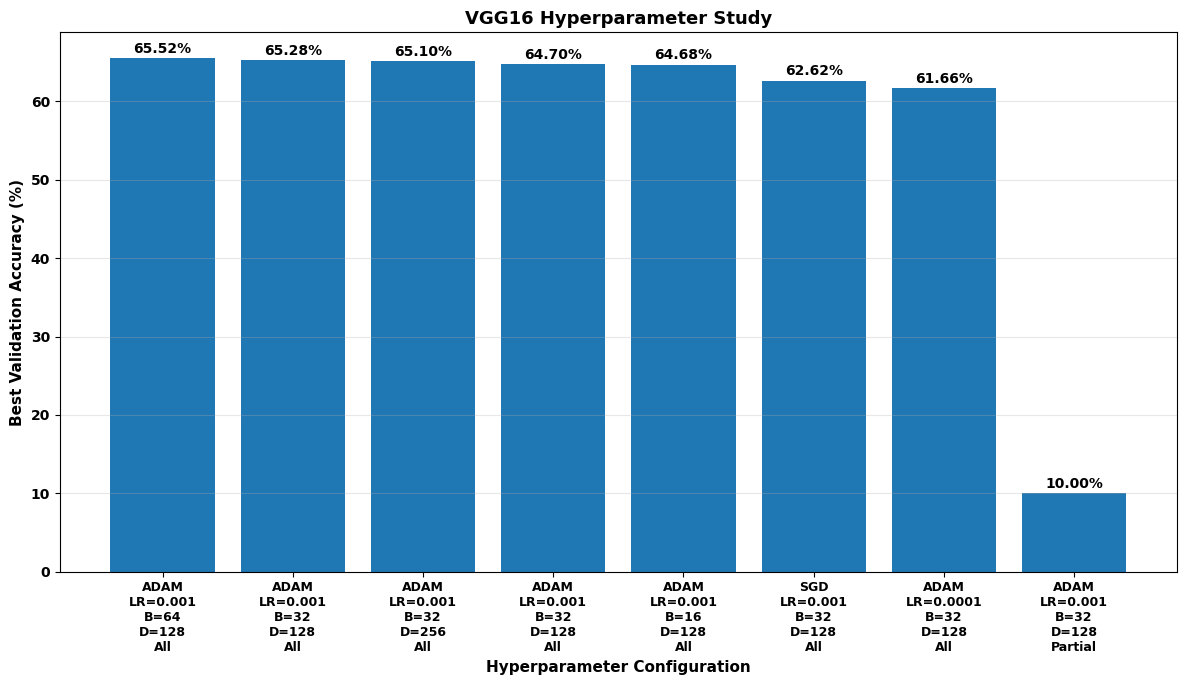


BEST HYPERPARAMETER CONFIGURATION
Optimizer      : ADAM
Learning Rate  : 0.001
Batch Size     : 64
Dense Units    : 128
Epochs         : 10
Frozen Layers  : All
Best Validation Accuracy : 65.52%


In [ ]:
# --------------------------------------------------
# HYPERPARAMETER STUDY COMPARISON PLOT
# --------------------------------------------------

# Sort configurations by validation accuracy
hp_plot_df = hp_df.sort_values(
    by='val_accuracy',
    ascending=False
).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(12, 7))

bars = ax.bar(
    range(len(hp_plot_df)),
    hp_plot_df['val_accuracy'] * 100
)

ax.set_title(
    'VGG16 Hyperparameter Study',
    fontweight='bold',
    fontsize=15
)

ax.set_xlabel(
    'Hyperparameter Configuration',
    fontweight='bold',
    fontsize=12
)

ax.set_ylabel(
    'Best Validation Accuracy (%)',
    fontweight='bold',
    fontsize=12
)

# Configuration labels
labels = []

for _, row in hp_plot_df.iterrows():

    optimizer = row['optimizer_name'].upper()
    lr = row['learning_rate']
    batch = row['batch_size']
    dense = row['dense_units']
    frozen = row['frozen_layers']

    label = (
        f"{optimizer}\n"
        f"LR={lr}\n"
        f"B={batch}\n"
        f"D={dense}\n"
        f"{frozen}"
    )

    labels.append(label)

ax.set_xticks(
    range(len(labels))
)

ax.set_xticklabels(
    labels,
    rotation=0,
    fontweight='bold',
    fontsize=9
)

ax.tick_params(
    axis='y',
    labelsize=10
)

# Add accuracy values above bars
for bar, value in zip(
    bars,
    hp_plot_df['val_accuracy'] * 100
):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.3,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=10
    )

ax.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

save_bold_plot(
    fig,
    'hyperparameter_comparison.png'
)

# --------------------------------------------------
# BEST CONFIGURATION
# --------------------------------------------------

best_hp = hp_plot_df.iloc[0]

print("\n" + "=" * 70)
print("BEST HYPERPARAMETER CONFIGURATION")
print("=" * 70)

print(
    "Optimizer      :",
    best_hp['optimizer_name'].upper()
)

print(
    "Learning Rate  :",
    best_hp['learning_rate']
)

print(
    "Batch Size     :",
    best_hp['batch_size']
)

print(
    "Dense Units    :",
    best_hp['dense_units']
)

print(
    "Epochs         :",
    int(best_hp['epochs'])
)

print(
    "Frozen Layers  :",
    best_hp['frozen_layers']
)

print(
    f"Best Validation Accuracy : "
    f"{best_hp['val_accuracy'] * 100:.2f}%"
)

print("=" * 70)

In [ ]:
# --------------------------------------------------
# ADAM vs SGD COMPARISON
# --------------------------------------------------

optimizer_configs = [
    {
        'name': 'Adam',
        'optimizer': optimizers.Adam(learning_rate=0.001)
    },
    {
        'name': 'SGD',
        'optimizer': optimizers.SGD(learning_rate=0.001)
    }
]

optimizer_results = []

for opt_config in optimizer_configs:

    print("\n" + "=" * 60)
    print(f"Training VGG16 using {opt_config['name']}")
    print("=" * 60)

    # Create a fresh VGG16 base
    base_opt = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    # Freeze convolutional base
    base_opt.trainable = False

    # Build classifier
    model_opt = models.Sequential([
        base_opt,
        layers.GlobalAveragePooling2D(),
        layers.Dense(128, activation='relu'),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])

    # Compile
    model_opt.compile(
        optimizer=opt_config['optimizer'],
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # Train
    start = time.time()

    history_opt = model_opt.fit(
        x_train_vgg,
        y_train,
        validation_data=(x_val_vgg, y_val),
        batch_size=32,
        epochs=10,
        verbose=1
    )

    elapsed = time.time() - start

    # Best validation accuracy
    best_val_acc_opt = max(
        history_opt.history['val_accuracy']
    )

    best_epoch_opt = (
        np.argmax(history_opt.history['val_accuracy']) + 1
    )

    optimizer_results.append({
        'Optimizer': opt_config['name'],
        'Best Validation Accuracy (%)':
            best_val_acc_opt * 100,
        'Best Epoch': best_epoch_opt,
        'Training Time (min)':
            elapsed / 60
    })

    print(
        f"\nBest Validation Accuracy: "
        f"{best_val_acc_opt * 100:.2f}%"
    )

    print(
        f"Best Epoch: {best_epoch_opt}"
    )

    print(
        f"Training Time: "
        f"{elapsed / 60:.2f} minutes"
    )

    del model_opt
    del base_opt
    tf.keras.backend.clear_session()


# --------------------------------------------------
# RESULTS DATAFRAME
# --------------------------------------------------

optimizer_df = pd.DataFrame(
    optimizer_results
)

print("\n" + "=" * 60)
print("ADAM vs SGD RESULTS")
print("=" * 60)

display(
    optimizer_df.round(2)
)


Training VGG16 using Adam
Epoch 1/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 17s 11ms/step - accuracy: 0.5336 - loss: 1.8961 - val_accuracy: 0.6090 - val_loss: 1.1747
Epoch 2/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6432 - loss: 1.0276 - val_accuracy: 0.6414 - val_loss: 1.0691
Epoch 3/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6765 - loss: 0.9284 - val_accuracy: 0.6430 - val_loss: 1.0756
Epoch 4/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.6950 - loss: 0.8732 - val_accuracy: 0.6440 - val_loss: 1.0670
Epoch 5/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7119 - loss: 0.8207 - val_accuracy: 0.6366 - val_loss: 1.1025
Epoch 6/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7290 - loss: 0.7695 - val_accuracy: 0.6424 - val_loss: 1.1260
Epoch 7/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step - accuracy: 0.7463 - loss: 0.7183 - val_accuracy: 0.6356 - val_loss: 1.1656
Epoch 8/10
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 9ms/step 

,Optimizer,Best Validation Accuracy (%),Best Epoch,Training Time (min)
0,Adam,64.40,4,2.15
1,SGD,62.36,10,2.31


Saved: plots/optimizer_comparison.png


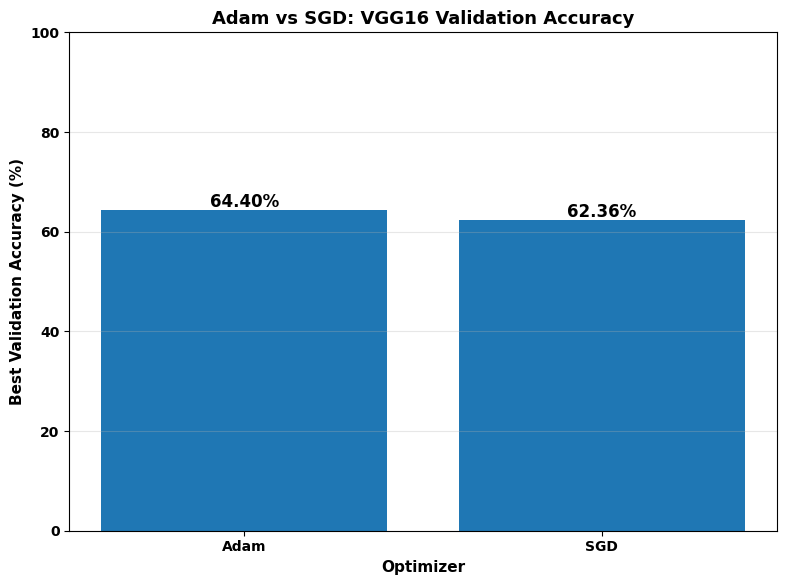


Optimizer comparison plot saved.


In [ ]:
# --------------------------------------------------
# ADAM vs SGD COMPARISON PLOT
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(8, 6))

bars = ax.bar(
    optimizer_df['Optimizer'],
    optimizer_df['Best Validation Accuracy (%)']
)

ax.set_title(
    'Adam vs SGD: VGG16 Validation Accuracy',
    fontweight='bold',
    fontsize=15
)

ax.set_xlabel(
    'Optimizer',
    fontweight='bold',
    fontsize=12
)

ax.set_ylabel(
    'Best Validation Accuracy (%)',
    fontweight='bold',
    fontsize=12
)

ax.set_ylim(
    0,
    max(100, optimizer_df['Best Validation Accuracy (%)'].max() + 10)
)

ax.grid(
    axis='y',
    alpha=0.3
)

for bar in bars:

    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f'{value:.2f}%',
        ha='center',
        fontweight='bold',
        fontsize=12
    )

plt.tight_layout()

save_bold_plot(
    fig,
    'optimizer_comparison.png'
)

print("\nOptimizer comparison plot saved.")

In [ ]:
# --------------------------------------------------
# CNN ARCHITECTURE COMPARISON
# LeNet-5, AlexNet, VGG16, ResNet50
# GoogleNet/Inception removed because InceptionV3
# requires a minimum input size of 75x75
# while CIFAR-10 images are 32x32.
# --------------------------------------------------

architecture_results = []


# --------------------------------------------------
# 1. LeNet-5
# --------------------------------------------------

def build_lenet5():

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(
            6,
            kernel_size=(5, 5),
            activation='tanh',
            padding='same'
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            16,
            kernel_size=(5, 5),
            activation='tanh'
        ),

        layers.AveragePooling2D(
            pool_size=(2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            120,
            activation='tanh'
        ),

        layers.Dense(
            84,
            activation='tanh'
        ),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=0.001
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# --------------------------------------------------
# 2. AlexNet
# --------------------------------------------------

def build_alexnet():

    model = models.Sequential([
        layers.Input(shape=INPUT_SHAPE),

        layers.Conv2D(
            96,
            kernel_size=(3, 3),
            strides=1,
            padding='same',
            activation='relu'
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            256,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Conv2D(
            384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),

        layers.Conv2D(
            384,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),

        layers.Conv2D(
            256,
            kernel_size=(3, 3),
            padding='same',
            activation='relu'
        ),

        layers.MaxPooling2D(
            pool_size=(2, 2)
        ),

        layers.Flatten(),

        layers.Dense(
            4096,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            4096,
            activation='relu'
        ),

        layers.Dropout(0.5),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=0.001
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# --------------------------------------------------
# 3. VGG16 TRANSFER LEARNING
# --------------------------------------------------

def build_vgg16_comparison():

    base = VGG16(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    base.trainable = False

    model = models.Sequential([
        base,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation='relu'
        ),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=0.001
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# --------------------------------------------------
# 4. RESNET50 TRANSFER LEARNING
# --------------------------------------------------

def build_resnet50_comparison():

    base = ResNet50(
        weights='imagenet',
        include_top=False,
        input_shape=INPUT_SHAPE
    )

    base.trainable = False

    model = models.Sequential([
        base,

        layers.GlobalAveragePooling2D(),

        layers.Dense(
            128,
            activation='relu'
        ),

        layers.Dense(
            NUM_CLASSES,
            activation='softmax'
        )
    ])

    model.compile(
        optimizer=optimizers.Adam(
            learning_rate=0.001
        ),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


# --------------------------------------------------
# MODEL CONFIGURATIONS
# --------------------------------------------------

architecture_configs = [

    (
        'LeNet-5',
        build_lenet5,
        x_train,
        x_val
    ),

    (
        'AlexNet',
        build_alexnet,
        x_train,
        x_val
    ),

    (
        'VGG16',
        build_vgg16_comparison,
        x_train_vgg,
        x_val_vgg
    ),

    (
        'ResNet50',
        build_resnet50_comparison,
        x_train_resnet,
        x_val_resnet
    )
]


# --------------------------------------------------
# TRAIN AND COMPARE
# --------------------------------------------------

ARCH_EPOCHS = 5
ARCH_BATCH_SIZE = 32

for name, build_fn, train_data, val_data in architecture_configs:

    print("\n" + "=" * 70)
    print(f"TRAINING: {name}")
    print("=" * 70)

    model_arch = build_fn()

    start_time_arch = time.time()

    history_arch = model_arch.fit(
        train_data,
        y_train,
        validation_data=(
            val_data,
            y_val
        ),
        epochs=ARCH_EPOCHS,
        batch_size=ARCH_BATCH_SIZE,
        verbose=1
    )

    elapsed_arch = time.time() - start_time_arch

    # --------------------------------------------------
    # BEST VALIDATION ACCURACY
    # --------------------------------------------------

    best_val_acc_arch = max(
        history_arch.history['val_accuracy']
    )

    best_epoch_arch = (
        np.argmax(
            history_arch.history['val_accuracy']
        ) + 1
    )

    # --------------------------------------------------
    # STORE RESULTS
    # --------------------------------------------------

    architecture_results.append({
        'Model': name,

        'Parameters':
            model_arch.count_params(),

        'Best Validation Accuracy (%)':
            best_val_acc_arch * 100,

        'Best Epoch':
            best_epoch_arch,

        'Training Time (min)':
            elapsed_arch / 60
    })

    # --------------------------------------------------
    # PRINT RESULTS
    # --------------------------------------------------

    print(
        f"\n{name} Best Validation Accuracy: "
        f"{best_val_acc_arch * 100:.2f}%"
    )

    print(
        f"{name} Parameters: "
        f"{model_arch.count_params():,}"
    )

    print(
        f"{name} Training Time: "
        f"{elapsed_arch / 60:.2f} minutes"
    )

    # Clear memory
    del model_arch
    tf.keras.backend.clear_session()


# --------------------------------------------------
# FINAL ARCHITECTURE RESULTS
# --------------------------------------------------

architecture_df = pd.DataFrame(
    architecture_results
)

print("\n" + "=" * 70)
print("CNN ARCHITECTURE COMPARISON RESULTS")
print("=" * 70)

display(
    architecture_df.round(2)
)


TRAINING: LeNet-5
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.3681 - loss: 1.7841 - val_accuracy: 0.4282 - val_loss: 1.6362
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.4562 - loss: 1.5389 - val_accuracy: 0.4872 - val_loss: 1.4696
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.4996 - loss: 1.4062 - val_accuracy: 0.5092 - val_loss: 1.4092
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.5308 - loss: 1.3254 - val_accuracy: 0.5144 - val_loss: 1.3847
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.5510 - loss: 1.2665 - val_accuracy: 0.5186 - val_loss: 1.3714

LeNet-5 Best Validation Accuracy: 51.86%
LeNet-5 Parameters: 83,126
LeNet-5 Training Time: 0.54 minutes

TRAINING: AlexNet
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 43s 25ms/step - accuracy: 0.0992 - loss: 2.3039 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 30s 21ms/step - accuracy: 0.0989 - loss

ValueError: Input size must be at least 75x75; Received: input_shape=(32, 32, 3)

In [ ]:
# --------------------------------------------------
# RESNET50 — ARCHITECTURE COMPARISON
# --------------------------------------------------

print("\n" + "=" * 70)
print("TRAINING: ResNet50")
print("=" * 70)

# Build ResNet50
resnet_arch = build_resnet50_comparison()

start_time_resnet = time.time()

history_resnet_arch = resnet_arch.fit(
    x_train_resnet,
    y_train,
    validation_data=(x_val_resnet, y_val),
    epochs=ARCH_EPOCHS,
    batch_size=ARCH_BATCH_SIZE,
    verbose=1
)

resnet_arch_time = time.time() - start_time_resnet

# Best validation accuracy
resnet_best_val_acc = max(
    history_resnet_arch.history['val_accuracy']
)

resnet_best_epoch = (
    np.argmax(
        history_resnet_arch.history['val_accuracy']
    ) + 1
)

resnet_params = resnet_arch.count_params()

# Store result
architecture_results.append({
    'Model': 'ResNet50',
    'Parameters': resnet_params,
    'Best Validation Accuracy (%)':
        resnet_best_val_acc * 100,
    'Best Epoch': resnet_best_epoch,
    'Training Time (min)':
        resnet_arch_time / 60
})

print("\n" + "=" * 70)
print("RESNET50 RESULTS")
print("=" * 70)

print(
    f"Best Validation Accuracy : "
    f"{resnet_best_val_acc * 100:.2f}%"
)

print(
    f"Parameters               : "
    f"{resnet_params:,}"
)

print(
    f"Training Time            : "
    f"{resnet_arch_time / 60:.2f} minutes"
)

print("=" * 70)

# --------------------------------------------------
# FINAL ARCHITECTURE DATAFRAME
# --------------------------------------------------

architecture_df = pd.DataFrame(
    architecture_results
)

display(
    architecture_df.round(2)
)


TRAINING: ResNet50
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Epoch 1/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 38s 19ms/step - accuracy: 0.5957 - loss: 1.1887 - val_accuracy: 0.6408 - val_loss: 1.0453
Epoch 2/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.6745 - loss: 0.9258 - val_accuracy: 0.6442 - val_loss: 1.0100
Epoch 3/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 14s 10ms/step - accuracy: 0.7043 - loss: 0.8318 - val_accuracy: 0.6620 - val_loss: 1.0134
Epoch 4/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7304 - loss: 0.7580 - val_accuracy: 0.6516 - val_loss: 1.0375
Epoch 5/5
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.7553 - loss: 0.6846 - val_accuracy: 0.6554 - val_loss: 1.0650

RESNET50 RESULTS
Best Validation Accuracy : 66.20%
Parameters               : 23,851,274
Training Time            : 1.54 minutes


,Model,Parameters,Best Validation Accuracy (%),Best Epoch,Training Time (min)
0,LeNet-5,83126,51.86,5,0.54
1,AlexNet,36925322,10.00,1,2.72
2,VGG16,14781642,65.34,5,1.12
3,ResNet50,23851274,66.20,3,1.54


Saved: plots/architecture_comparison.png


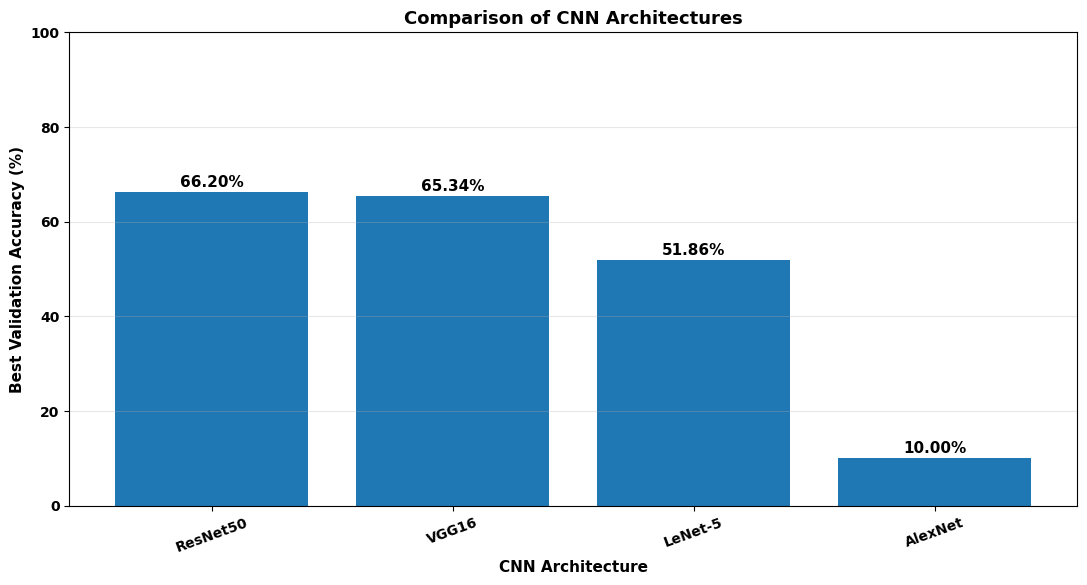


CNN ARCHITECTURE COMPARISON


,Model,Parameters,Best Validation Accuracy (%),Best Epoch,Training Time (min)
0,ResNet50,23851274,66.20,3,1.54
1,VGG16,14781642,65.34,5,1.12
2,LeNet-5,83126,51.86,5,0.54
3,AlexNet,36925322,10.00,1,2.72



Saved: plots/architecture_comparison_results.csv


In [ ]:
# --------------------------------------------------
# CNN ARCHITECTURE COMPARISON PLOT
# GoogleNet/Inception REMOVED
# --------------------------------------------------

# Keep only successfully evaluated architectures
architecture_plot_df = architecture_df[
    architecture_df['Model'].isin([
        'LeNet-5',
        'AlexNet',
        'VGG16',
        'ResNet50'
    ])
].copy()

# Sort by validation accuracy
architecture_plot_df = architecture_plot_df.sort_values(
    by='Best Validation Accuracy (%)',
    ascending=False
).reset_index(drop=True)


# --------------------------------------------------
# PLOT
# --------------------------------------------------

fig, ax = plt.subplots(figsize=(11, 6))

bars = ax.bar(
    architecture_plot_df['Model'],
    architecture_plot_df['Best Validation Accuracy (%)']
)

ax.set_title(
    'Comparison of CNN Architectures',
    fontweight='bold',
    fontsize=15
)

ax.set_xlabel(
    'CNN Architecture',
    fontweight='bold',
    fontsize=12
)

ax.set_ylabel(
    'Best Validation Accuracy (%)',
    fontweight='bold',
    fontsize=12
)

ax.set_ylim(
    0,
    max(
        100,
        architecture_plot_df['Best Validation Accuracy (%)'].max() + 10
    )
)

ax.tick_params(
    axis='x',
    labelrotation=20
)

for label in ax.get_xticklabels():
    label.set_fontweight('bold')

for label in ax.get_yticklabels():
    label.set_fontweight('bold')


# Add accuracy values above bars
for bar in bars:

    value = bar.get_height()

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.5,
        f'{value:.2f}%',
        ha='center',
        va='bottom',
        fontweight='bold',
        fontsize=11
    )

ax.grid(
    axis='y',
    alpha=0.3
)

plt.tight_layout()

save_bold_plot(
    fig,
    'architecture_comparison.png'
)


# --------------------------------------------------
# FINAL ARCHITECTURE COMPARISON TABLE
# --------------------------------------------------

print("\n" + "=" * 80)
print("CNN ARCHITECTURE COMPARISON")
print("=" * 80)

display(
    architecture_plot_df.round(2)
)


# --------------------------------------------------
# SAVE RESULTS
# --------------------------------------------------

architecture_plot_df.to_csv(
    os.path.join(
        PLOTS_DIR,
        'architecture_comparison_results.csv'
    ),
    index=False
)

print(
    "\nSaved:",
    os.path.join(
        PLOTS_DIR,
        'architecture_comparison_results.csv'
    )
)

In [ ]:
# --------------------------------------------------
# FINAL RESULTS SUMMARY — SECTION 18.1
# --------------------------------------------------

# Best training and validation accuracy from main transfer learning
best_training_accuracy = max(
    history_vgg.history['accuracy']
)

best_validation_accuracy = max(
    history_vgg.history['val_accuracy']
)

# Best validation accuracy after fine-tuning
best_finetuned_validation_accuracy = max(
    history_ft.history['val_accuracy']
)

# --------------------------------------------------
# CREATE FINAL RESULTS TABLE
# --------------------------------------------------

final_results = pd.DataFrame({
    'Metric': [
        'Best Training Accuracy',
        'Best Validation Accuracy Before Fine-Tuning',
        'Best Validation Accuracy After Fine-Tuning',
        'Testing Accuracy',
        'Precision (Macro)',
        'Recall (Macro)',
        'F1-score (Macro)',
        'Total Parameters',
        'Initial Training Time (min)',
        'Fine-Tuning Time (min)'
    ],

    'Value': [
        f'{best_training_accuracy * 100:.2f}%',
        f'{best_validation_accuracy * 100:.2f}%',
        f'{best_finetuned_validation_accuracy * 100:.2f}%',
        f'{test_accuracy * 100:.2f}%',
        f'{test_precision * 100:.2f}%',
        f'{test_recall * 100:.2f}%',
        f'{test_f1 * 100:.2f}%',
        f'{vgg_model.count_params():,}',
        f'{training_time_vgg / 60:.2f}',
        f'{fine_tuning_time / 60:.2f}'
    ]
})

# --------------------------------------------------
# DISPLAY FINAL RESULTS
# --------------------------------------------------

print("=" * 70)
print("SECTION 18.1 — FINAL VGG16 PERFORMANCE METRICS")
print("=" * 70)

display(final_results)

# --------------------------------------------------
# SAVE FINAL RESULTS
# --------------------------------------------------

final_results.to_csv(
    os.path.join(
        PLOTS_DIR,
        'final_vgg16_results.csv'
    ),
    index=False
)

print(
    "\nSaved:",
    os.path.join(
        PLOTS_DIR,
        'final_vgg16_results.csv'
    )
)

print("=" * 70)

SECTION 18.1 — FINAL VGG16 PERFORMANCE METRICS


,Metric,Value
0,Best Training Accuracy,83.75%
1,Best Validation Accuracy Before Fine-Tuning,64.96%
2,Best Validation Accuracy After Fine-Tuning,69.82%
3,Testing Accuracy,69.76%
4,Precision (Macro),69.75%
5,Recall (Macro),69.76%
6,F1-score (Macro),69.70%
7,Total Parameters,"14,781,642"
8,Initial Training Time (min),3.18
9,Fine-Tuning Time (min),2.49



Saved: plots/final_vgg16_results.csv
